In [1]:
import os
import torch
import numpy as np
from torch_geometric.loader import DataLoader
from datetime import datetime
from function_libraries.generation_graph import parallel_gen_graph
from GNN_model.GNN import *
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

c:\Users\imagi\anaconda3\envs\CML_GNN\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
number_of_color =3
device = "cuda"
input_combination =[3,3 , 6, 3, 10 ,20, 3]

evalu_data_dense = [d for d, _ in parallel_gen_graph(num_graph = 100,
                                number_of_color = number_of_color,
                                number_initial_liposome = 3,
                                number_merging_liposome =3,
                                merging_distance_thres = 3,
                                distance_thres = 60,
                                percentage_blinking = 6,
                                noise_percentage = 3, 
                                number_of_weak_FI = 10,
                                blinking = 6, 
                                initial_t = 0,
                                end_t = 2500,
                                random_time_interval = 200, 
                                concentration =20,
                                number_of_neighboring_liposome = 3,
                                merging_GT_strategy = "exact",
                                deterministic = True,
                                combinatorial = True,
                                number_of_core = 10)] 

#The bellow will remove the outlier graphs with too many nodes or edges
num_nodes = []
for d in evalu_data_dense:
    d.x = d.x[:,0:3+number_of_color]
    num_nodes.append(d.x.shape[0])
outlier_nodes = np.percentile(num_nodes,80)
safe_node_index = np.where(outlier_nodes>num_nodes)[0]
evalu_data_dense = [evalu_data_dense[i] for i in safe_node_index]
num_edges = []
for d in evalu_data_dense:
    num_edges.append(d.y.shape[0])    
outlier_edges = np.percentile(num_edges,80)
safe_edge_index = np.where(outlier_edges>num_edges)[0]
evalu_data_dense = [evalu_data_dense[i] for i in safe_edge_index]

Graph generation: 100%|██████████| 100/100 [00:07<00:00, 14.20it/s]


<div style="color:gray">
    
- __parallel_gen_graph__: generate simulated input graph that can be used for training and estimation. parallel_gen_graph function has the following variables:<br>
- __num_graph__: the number of simulated graph generated.<br>
- __number_of_color__: the number of available color for the vertex information. number_of_color = 1 mean the vertex has single color information.<br>
![merging_strategy](assets/initial_liposome.png)<br>
- __number_initial_liposome__: the number of ground truth particle trajectories appear in the graph.<br>
- __number_merging_liposome__: the number of ground truth particle trajectories that merge with other particle. If number_initial_liposome = 5 and
number_merging_liposome = 2, there will be 7 ground truth trajectories and 2 merging event.<br>
- __merging_distance_thres__: if two vertices are approached within merging_distance_thres, the two vertices will become a single vertex.<br>
- __distance_thres__: the maximum edge distance of ground truth trajectory.<br>
- __percentage_blinking__: the probability (max = 100) of blinking of ground truth trajectories.<br>
- __noise_percentage__: the relative percentage of false-positive noise vertex in every frame.<br>
- __number_of_weak_Fl__: the number of weak intensity particle trajectorie. In experimental situation, some of particles' intensities are in the threshold range of the detection limit. Therefore, exhibit frequently blinking particle emergence. The model distingush such frequently blinking vertex and does not connect the edges.<br>
- __blinking:__ the maximum number of continuos disappearing of ground truth particle trajectory.<br>
- __initial_t__: the starting time of the graph.<br>
- __end_t__: the ending time of the graph.<br>
- __random_time_interval__: the time interval of the graph.<br>
- __number_of_neighboring_liposome__: the percentage of false-positive particle relative to ground truth vertex (particles) appearing near the ground 
truth vertex.<br>
- __merging_GT_strategy__: the graph construction method. "exact": the merged particles are connected by two vertex through two edges. "jumping": there is no merging, but disappearing of particle.<br>
![merging_strategy](assets/merging_strategy.png).<br>
- __deterministic__: if deterministic == True, apply the above parameters exactly. If deterministic == False, [number_of_neighboring_liposome,noise_percentage, percentage_blinking, number_of_weak_FI] are randomly selected from the lower value of the above setting. <br>
- __combinatorial__: if combinatorial == Ture, simulate the particle in the presence of combinatorial color mixture for the single particle. If combinatorial == False, single particles can only have a single color. <br>
- __number_of_core__: the number of CPU cores for the sample generation.<br>

In [ ]:
#We can mix different input setting to generate evaluation data to test the model robustness.
input_combination = [7,4, 6, 3, 12 ,1, 12]

evalu_data_sparse = [d for d, _ in parallel_gen_graph(num_graph = 100,
                                number_of_color = number_of_color,
                                number_initial_liposome = input_combination[0],
                                number_merging_liposome =input_combination[1],
                                merging_distance_thres = 3,
                                distance_thres = 60,
                                percentage_blinking = input_combination[2],
                                noise_percentage = input_combination[3], 
                                number_of_weak_FI = input_combination[4],
                                blinking = 6, 
                                initial_t = 0,
                                end_t = 2500,
                                random_time_interval = 200, 
                                concentration =input_combination[5],
                                number_of_neighboring_liposome = input_combination[6],
                                merging_GT_strategy = "exact",
                                deterministic = True,
                                combinatorial = True,
                                number_of_core = 10)]


num_nodes = []
for d in evalu_data_sparse:
    d.x = d.x[:,0:3+number_of_color]
    num_nodes.append(d.x.shape[0])
outlier_nodes = np.percentile(num_nodes,80)
safe_node_index = np.where(outlier_nodes>num_nodes)[0]
evalu_data_sparse = [evalu_data_sparse[i] for i in safe_node_index]
num_edges = []
for d in evalu_data_sparse:
    num_edges.append(d.y.shape[0])    
outlier_edges = np.percentile(num_edges,80)
safe_edge_index = np.where(outlier_edges>num_edges)[0]
evalu_data_sparse = [evalu_data_sparse[i] for i in safe_edge_index]


Graph generation: 100%|██████████| 100/100 [00:07<00:00, 14.25it/s]


In [4]:

input_combination = [3,2 , 6, 3, 10 ,20, 3]
train_data_dense = [d for d, _ in parallel_gen_graph(num_graph = 100,
                                number_of_color = number_of_color,
                                number_initial_liposome = input_combination[0],
                                number_merging_liposome =input_combination[1],
                                merging_distance_thres = 3,
                                distance_thres = 60,
                                percentage_blinking = input_combination[2],
                                noise_percentage = input_combination[3], #[0,60],
                                number_of_weak_FI = input_combination[4],
                                blinking = 6, 
                                initial_t = 0,
                                end_t = 2500,
                                random_time_interval = 200, #200,  #0 if the interval is given as initial_t and end_t, must smaller than 2500 and bigger than 0
                                concentration =input_combination[5],
                                number_of_neighboring_liposome = input_combination[6],
                                merging_GT_strategy = "exact",
                                deterministic = True,
                                combinatorial = True,
                                number_of_core = 10)] #1 for entire distribution 40 for mininum



num_nodes = []
for d in train_data_dense:
    d.x = d.x[:,0:3+number_of_color]
    num_nodes.append(d.x.shape[0])
outlier_nodes = np.percentile(num_nodes,80)
safe_node_index = np.where(outlier_nodes>num_nodes)[0]
train_data_dense = [train_data_dense[i] for i in safe_node_index]
num_edges = []
for d in train_data_dense:
    num_edges.append(d.y.shape[0])    
outlier_edges = np.percentile(num_edges,80)
safe_edge_index = np.where(outlier_edges>num_edges)[0]
train_data_dense = [train_data_dense[i] for i in safe_edge_index]


Graph generation: 100%|██████████| 100/100 [00:07<00:00, 14.08it/s]


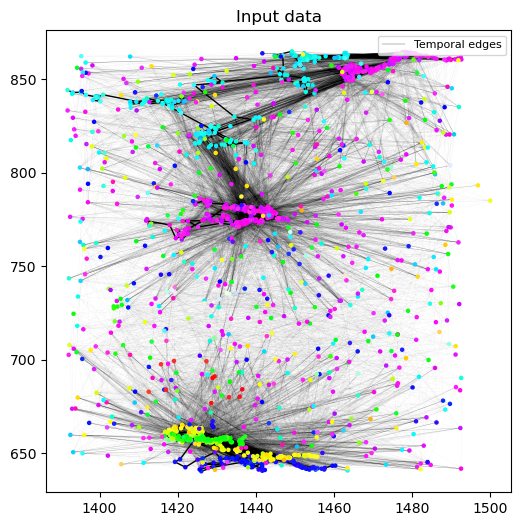

In [5]:
fig, axes = plt.subplots(1, 1, figsize=(6,6 ))

edge_index = train_data_dense[0].edge_index.cpu().numpy() 
edges = edge_index.T                                    
GT = train_data_dense[0].y.cpu().numpy()
vertex = train_data_dense[0].x.cpu().numpy()

color = vertex[:,3:6]/vertex[:,3:6].max(axis=1)[:,np.newaxis]
for i, (u, v) in enumerate(edges):
    x0, y0 = vertex[int(u), 0], vertex[int(u), 1]
    x1, y1 = vertex[int(v), 0], vertex[int(v), 1]
    axes.plot([x0, x1], [y0, y1], color="k", linewidth=0.1, alpha = 0.1)

axes.scatter(vertex[:,0], vertex[:,1], color = color, s=5, zorder=3)
legend_handles = [Line2D([0],[0], color='k', lw=0.2, label='Temporal edges')]
axes.legend(handles=legend_handles, loc='upper right', fontsize=8)
axes.set_title("Input data")

edges_GT = edges[GT == 1]

for i, (u, v) in enumerate(edges_GT):
    
    x0, y0 = vertex[int(u), 0], vertex[int(u), 1]
    x1, y1 = vertex[int(v), 0], vertex[int(v), 1]
    axes.plot([x0, x1], [y0, y1], color="k",linewidth = 1 )


The above plot shows time projected dense trajectory data. The colored dots are the vertexes (colored particle) and black lines are temporal edeges.

In [6]:
input_combination = [5, 5, 6, 3, 12 ,1, 12]
train_data_sparse = [d for d, _ in parallel_gen_graph(num_graph = 100,
                                number_of_color = number_of_color,
                                number_initial_liposome = input_combination[0],
                                number_merging_liposome =input_combination[1],
                                merging_distance_thres = 3,
                                distance_thres = 60,
                                percentage_blinking = input_combination[2],
                                noise_percentage = input_combination[3], #[0,60],
                                number_of_weak_FI = input_combination[4],
                                blinking = 6, 
                                initial_t = 0,
                                end_t = 2500,
                                random_time_interval = 200, #200,  #0 if the interval is given as initial_t and end_t, must smaller than 2500 and bigger than 0
                                concentration =input_combination[5],
                                number_of_neighboring_liposome = input_combination[6],
                                merging_GT_strategy = "exact",
                                deterministic = True,
                                combinatorial = True,
                                number_of_core = 10)] #1 for entire distribution 40 for mininum


num_nodes = []
for d in train_data_sparse:
    d.x = d.x[:,0:3+number_of_color]
    num_nodes.append(d.x.shape[0])
outlier_nodes = np.percentile(num_nodes,80)
safe_node_index = np.where(outlier_nodes>num_nodes)[0]
train_data_sparse = [train_data_sparse[i] for i in safe_node_index]
num_edges = []
for d in train_data_sparse:
    num_edges.append(d.y.shape[0])    
outlier_edges = np.percentile(num_edges,80)
safe_edge_index = np.where(outlier_edges>num_edges)[0]
train_data_sparse = [train_data_sparse[i] for i in safe_edge_index]


Graph generation:   0%|          | 0/100 [00:00<?, ?it/s]

Graph generation: 100%|██████████| 100/100 [00:07<00:00, 13.22it/s]


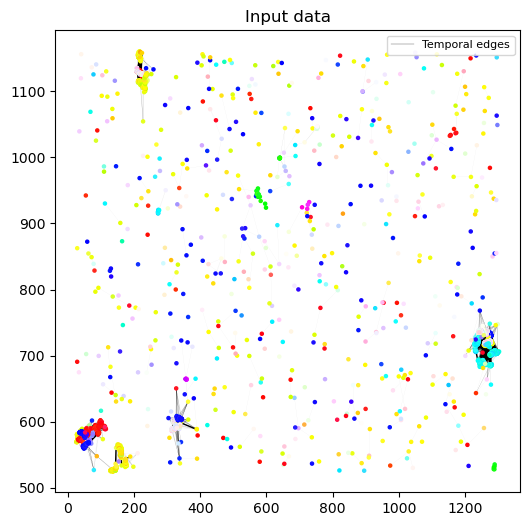

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(6,6 ))

edge_index = train_data_sparse[0].edge_index.cpu().numpy() 
edges = edge_index.T                                    
GT = train_data_sparse[0].y.cpu().numpy()
vertex = train_data_sparse[0].x.cpu().numpy()

color = vertex[:,3:6]/vertex[:,3:6].max(axis=1)[:,np.newaxis]
for i, (u, v) in enumerate(edges):
    x0, y0 = vertex[int(u), 0], vertex[int(u), 1]
    x1, y1 = vertex[int(v), 0], vertex[int(v), 1]
    axes.plot([x0, x1], [y0, y1], color="k", linewidth=0.1, alpha = 0.1)

axes.scatter(vertex[:,0], vertex[:,1], color = color, s=5, zorder=3)
legend_handles = [Line2D([0],[0], color='k', lw=0.2, label='Temporal edges')]
axes.legend(handles=legend_handles, loc='upper right', fontsize=8)
axes.set_title("Input data")

edges_GT = edges[GT == 1]

for i, (u, v) in enumerate(edges_GT):
    
    x0, y0 = vertex[int(u), 0], vertex[int(u), 1]
    x1, y1 = vertex[int(v), 0], vertex[int(v), 1]
    axes.plot([x0, x1], [y0, y1], color="k",linewidth = 1 )


The above plot shows time projected sparse trajectory data. Note the x and y axis difference of this plot to the dense graph plot.

In [8]:
#Combine different training data
train_data = train_data_dense + train_data_sparse
evalu_data = evalu_data_sparse + evalu_data_dense

Depending on the situation, different training data can be merged.

The example above is merging a sparse and dense trajectories.

In [9]:
#scaler = torch.amp.GradScaler(enabled = True)  
#gc.collect()
#torch.cuda.empty_cache()


train_loader = DataLoader(train_data , batch_size=1)
test_loader =DataLoader(evalu_data , batch_size=1)


t_loss_v = []
t_acc_v = []
v_loss_v = []
v_acc_v = []
False_negative_thres_list = []
ep = 0
weight = 2
m_configs = {"input_dim": 3+number_of_color, "hidden_dim": 64, "iteration":5 ,  "n_graph_iters": 5, "number_of_color": number_of_color, "layer_norm": True} 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AGNN_Network(**m_configs)
model.to(device)


optimizer = torch.optim.AdamW(model.parameters(), lr=0.0002,  amsgrad=True) # lr=0.00002

today = datetime.now()
date = str(today.date())

timestr = today.strftime("%Hh%Mm%Ss")
path = "model_save/" + date + "/"+ timestr +"/"
os.makedirs(path)


for epoch in range(10):
    ep += 1  
    model.train()
    #acc, total_loss = train(model, train_loader, optimizer)
    acc, total_loss = train(model, train_loader, optimizer)
    t_loss_v.append(total_loss)
    t_acc_v.append(acc)
    #if ep%10 ==0:
    print('Epoch: {}, Accuracy: {:.15f},  Total_loss: {:.15f}'.format(ep, acc, total_loss))        
    np.savetxt(path + "acc_train.txt" ,t_acc_v)   
    np.savetxt(path + "loss_train.txt" ,t_loss_v)

    if len(t_acc_v[:-1])>0:
        if t_acc_v[-1] > max(t_acc_v[:-1]):
            torch.save(model, path + "trained_acc.pt")
        if t_loss_v[-1] < min(t_loss_v[:-1]):
            torch.save(model, path + "trained_loss.pt")
    else:
        torch.save(model, path + "trained_acc.pt")
        torch.save(model, path + "trained_loss.pt")
        

    with torch.no_grad():
        model.eval()
        acc, total_loss, true_positive, true_negative, False_positive, False_negative = evaluate(model, test_loader)
        v_loss_v.append(total_loss)
        v_acc_v.append(acc)
        False_negative_thres_list.append(False_negative)
        print('Epoch: {}, Accuracy: {:.3f},  Total_loss: {:.3f}, true_positive: {:.0f}, true_negative: {:.0f}, False_positive: {:.0f}, False_negative: {:.0f} '.format(ep, acc, total_loss, true_positive, true_negative,False_positive, False_negative))

        np.savetxt(path + "acc_valid.txt" ,v_acc_v)
        np.savetxt(path + "loss_valid.txt" ,v_loss_v)
        np.savetxt(path + "false_positive.txt" ,False_negative_thres_list)
        if len(v_acc_v) > 2:
            if v_acc_v[-1] > max(v_acc_v[:-1]):
                torch.save(model, path + "evaluate_acc.pt")
            if v_loss_v[-1] < min(v_loss_v[:-1]):
                torch.save(model, path + "evaluate_loss.pt")            

    #add saving based on validation results

Epoch: 1, Accuracy: 0.279436133116063,  Total_loss: 20.660128146409988
Epoch: 1, Accuracy: 0.885,  Total_loss: 8.001, true_positive: 242729, true_negative: 6486894, False_positive: 2696, False_negative: 28860 
Epoch: 2, Accuracy: 0.886720353057156,  Total_loss: 6.237365148961544
Epoch: 2, Accuracy: 0.888,  Total_loss: 5.277, true_positive: 243723, true_negative: 6486834, False_positive: 2756, False_negative: 27867 
Epoch: 3, Accuracy: 0.890330677395239,  Total_loss: 4.499186865985394
Epoch: 3, Accuracy: 0.893,  Total_loss: 4.314, true_positive: 245323, true_negative: 6486333, False_positive: 3257, False_negative: 26266 
Epoch: 4, Accuracy: 0.897762240979678,  Total_loss: 3.555759064853191
Epoch: 4, Accuracy: 0.924,  Total_loss: 2.998, true_positive: 254988, true_negative: 6485150, False_positive: 4437, False_negative: 16601 
Epoch: 5, Accuracy: 0.935459892044067,  Total_loss: 2.392648748122156
Epoch: 5, Accuracy: 0.960,  Total_loss: 1.851, true_positive: 263446, true_negative: 6486701,

The above training procedure will save the best weights of the model based on the accuracy or loss function in seperate file directories.

The trained weight will be used in the inference.